##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount("/google_drive")

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/내 Mac/sec07"
    print("\n[작업 폴더 목록]")
    %cd "{WORK_DIR}"
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/cifar10"
    DATASET_ZIP = f"{WORK_DIR}/datasets/cifar10.zip"
    !mkdir -p "{DATASET_PATH}"
    !cp -n "{DATASET_ZIP}" "{DATASET_PATH}.zip"
    !unzip -qn "{DATASET_PATH}.zip" -d "{DATASET_PATH}"
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls "{DATASET_PATH}"
    print()

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 로컬 실행 경로 및 데이터셋 경로 설정
    import os
    WORK_DIR = os.getcwd()
    DATASET_PATH = "../datasets/cifar10"

    # 로컬 dataset 폴더 접근 확인
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec07
01_dataset_dataloader.ipynb  07_transfer_learning_resnet.ipynb
02_cnn_model.ipynb	     08_transfer_learning_efficientnet.ipynb
03_train.ipynb		     datasets
04_cnn_model_gap.ipynb	     saved_models_data_augmentation
05_train_gap.ipynb	     saved_models_efficientnet
06_data_augmentation.ipynb   saved_models_resnet

[데이터셋 폴더 목록]
/datasets/cifar10
test  train  val

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 임포트

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import copy
import os

##### Device 설정

In [3]:
# Colab에서는 CUDA, Apple Silicon Mac에서는 MPS, 그 외에는 CPU 사용
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"사용 장치: {device}")

사용 장치: cuda


##### RGB 평균/표준편차 계산 함수

In [4]:
# def calculate_mean_std(path:str):
#     """훈련 데이터셋의 채널별(RGB)평균/표준편차를 계산하는 함수"""
#     # Dataset 생성
#     train_dataset = datasets.ImageFolder(
#         path,
#         transform=transforms.ToTensor()   # 픽셀값을 0~1 범위로 스케일 변환만 적용
#     )

#     # 배치 단위로 데이터를 불러오기 위해 DataLoader 생성
#     train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)

#     # 채널별 누적합을 저장할 Tensor 초기화
#     channel_sum    = torch.zeros(3)

#     # 채널별 제곱 누적합을 저장할 Tensor 초기화
#     channel_sum_sq = torch.zeros(3)

#     # 전체 픽셀 수를 저장할 변수 초기화
#     pixel_count    = 0

#     # DataLoader로 배치 단위로 데이터를 불러옴
#     for images, _ in train_loader:
#         # images shape: (batch, 3, 32, 32)
#         channel_sum    += images.sum(dim=[0, 2, 3])      # 배치·높이·너비 방향 합산
#         channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
#         pixel_count    += images.shape[0] * images.shape[2] * images.shape[3]

#     # 채널별 평균과 표준편차 계산
#     mean = channel_sum / pixel_count                         # tensor shape: (3,)
#     std  = (channel_sum_sq / pixel_count - mean ** 2).sqrt() # tensor shape: (3,)

#     return mean.tolist(), std.tolist()

# # 훈련 데이터셋의 채널별 평균과 표준편차 계산
# mean, std = calculate_mean_std("data/cifar10/train")
# print("CIFAR-10 훈련 데이터셋의 채널별 평균:", mean)
# print("CIFAR-10 훈련 데이터셋의 채널별 표준편차:", std)

# CIFAR-10 훈련 데이터셋의 채널별 평균: [0.491350919008255, 0.48206818103790283, 0.4465498626232147]
# CIFAR-10 훈련 데이터셋의 채널별 표준편차: [0.24713236093521118, 0.2436210662126541, 0.2617213726043701]

##### Transform 정의(데이터 증강 포함)

In [5]:
# 앞에서 계산한 mean, std를 튜플로 변환해 사용
# RGB_MEAN = tuple(mean)  # R, G, B 채널 평균
# RGB_STD  = tuple(std)   # R, G, B 채널 표준편차

RGB_MEAN = (0.491350919008255, 0.48206818103790283, 0.4465498626232147)   # R, G, B 채널 평균
RGB_STD  = (0.24713236093521118, 0.2436210662126541, 0.2617213726043701)  # R, G, B 채널 표준편차

# 훈령용 전처리 파이프라인 정의
# - 데이터 증강을 적용하여 모델 일반화 성능 향상
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),      # 50% 확률로 좌우 반전
    transforms.RandomCrop(32, padding=4),   # 테두리 4px 패딩 후 32×32 랜덤 크롭해서 상하좌우 이동
    transforms.ToTensor(), # PIL Image (H, W, C) -> Tensor (C, H, W) float32 0.0 ~ 1.0 로 변환
    transforms.Normalize(RGB_MEAN, RGB_STD) # 채널별로 표준화된 데이터로 변환
])

# 검증/테스트용 전처리 파이프라인 정의
# - 데이터 증강 없이 원본 이미지 그대로 평가
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(RGB_MEAN, RGB_STD),
])

##### 훈련/검증/테스트별로 Dataset 생성  

In [6]:
# ImageFolder를 이용해서 Dataset 생성
train_dataset = datasets.ImageFolder(DATASET_PATH + "/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH + "/val",   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(DATASET_PATH + "/test",  transform=val_test_transform)

print(f"학습 데이터셋 크기  : {len(train_dataset):5d} 개")
print(f"검증 데이터셋 크기  : {len(val_dataset):5d} 개")
print(f"테스트 데이터셋 크기: {len(test_dataset):5d} 개")
print(f"클래스 목록: {train_dataset.classes}")
print(f"클래스 인덱스: {train_dataset.class_to_idx}")

학습 데이터셋 크기  : 45000 개
검증 데이터셋 크기  :  5000 개
테스트 데이터셋 크기: 10000 개
클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
클래스 인덱스: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


##### 훈련/검증/테스트별로 DataLoader 생성

In [7]:
# 배치 크기 설정
# - 작을 수록(16~32): 일반화 성능 UP, 과적합 방지에 유리, 학습 속도 Down, GPU를 충분히 활용하지 못함
# - 클수록(128~512): 일반화 성능 Down, 과적합 발생 증가 가능, 학습 속도 UP, GPU를 충분히 활용
# - 64: GPU 메모리 사용량과 학습 속도, 일반화 성능을 적절히 고려한 값으로, 대부분의 경우 적절한 선택
BATCH_SIZE  = 64

# DataLoader에서 데이터를 불러올 때 사용할 워커(worker) 수
# 무료 코랩은 보통 CPU 2코어 제공. 코어 수보다 많은 worker는 효과 없고 오히려 오버헤드 발생
NUM_WORKERS = 2

# 훈련용 DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # 매 에포크마다 순서를 섞어 과적합 방지
    num_workers=NUM_WORKERS,
)

# 검증용 DataLoader 생성
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)

# 테스트용 DataLoader 생성
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)

print(f"train 배치 수: {len(train_loader)}")   # 45000 / 64 = 704
print(f"val   배치 수: {len(val_loader)}")     # 5000  / 64 = 79
print(f"test  배치 수: {len(test_loader)}")    # 10000 / 64 = 157


train 배치 수: 704
val   배치 수: 79
test  배치 수: 157


##### 배치 데이터 확인

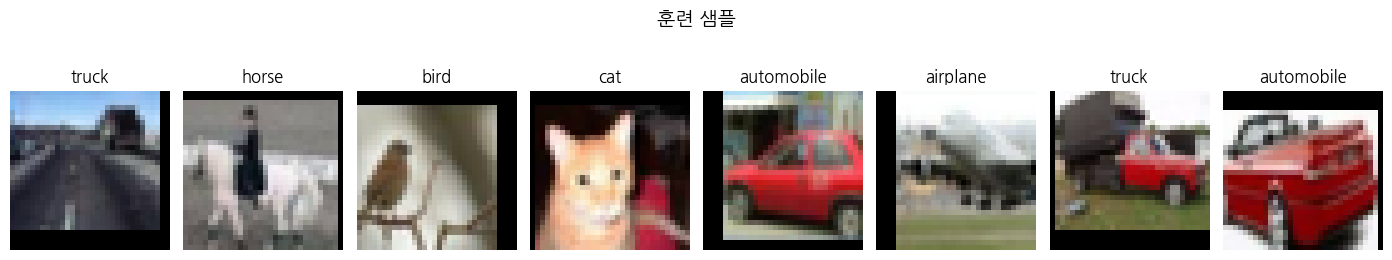

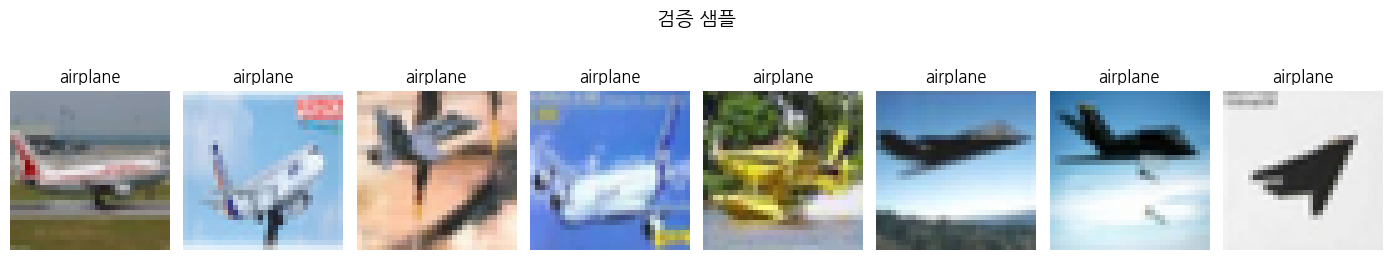

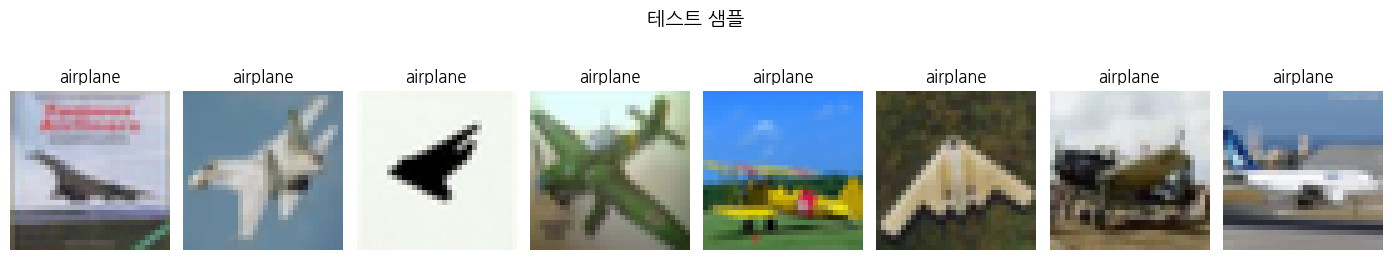

In [8]:
# DataLoader에서 배치 단위로 샘플 이미지를 시각화하는 함수
def show_batch_sample(title:str, dataset:Dataset, loader:DataLoader, rgb_mean:tuple, rgb_std:tuple):
    # DataLoader에서 첫 번째 배치 꺼내기
    # images: (batch_size, 3, 32, 32) 형태의 Tensor
    # labels: (batch_size,) 형태의 Tensor
    images, labels = next(iter(loader))

    # 배치에서 샘플 이미지 8장을 보여줄 서브 플롯 생성
    fig, axes = plt.subplots(1, 8, figsize=(14, 3))
    fig.suptitle(title, fontsize=14)

    # view(3, 1, 1): 브로드캐스팅을 위해 (3,) → (3, 1, 1) 형태로 변환
    mean = torch.tensor(rgb_mean).view(3, 1, 1)
    std  = torch.tensor(rgb_std).view(3, 1, 1)

    # images[:8]: 배치에서 처음 8장 이미지 선택 (shape: (8, 3, 32, 32))
    for ax, img, lbl in zip(axes, images[:8], labels[:8]):
        # DataLoader로 불러온 이미지는 이미 표준화된 상태이므로, 시각화를 위해 표준화 역변환을 수행
        # 표준화 역변환: (표준화된 값 × std) + mean
        img_display = img * std + mean
        # 픽셀값을 0~1 범위로 클리핑 (표준화 역변환 후 범위를 벗어나는 값 보정)
        # -0.05  →  0.0   (하한 보정)
        #  0.53  →  0.53  (그대로)
        #  1.02  →  1.0   (상한 보정)
        img_display = img_display.clamp(0, 1)   # 픽셀값을 0~1 범위로 클램프
        # (C, H, W) → (H, W, C)
        img_display = img_display.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)

        ax.imshow(img_display)
        ax.set_title(dataset.classes[lbl], fontsize=12)
        ax.axis("off")

    plt.tight_layout(pad=1)
    plt.show()

show_batch_sample("훈련 샘플", train_dataset, train_loader, RGB_MEAN, RGB_STD)
show_batch_sample("검증 샘플", val_dataset, val_loader, RGB_MEAN, RGB_STD)
show_batch_sample("테스트 샘플", test_dataset, test_loader, RGB_MEAN, RGB_STD)


##### 이미지 분류 모델 정의 및 생성

In [ ]:
class Cifar10Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        # ------------------------------------------------------------------
        # Conv Block 1
        # 1) Conv2d: 입력 3채널(RGB) → 출력 32채널 (저수준 특징 추출)
        #   - in_channels=3: RGB 이미지의 3개 채널(빨강, 초록, 파랑)
        #   - out_channels=32: 학습할 필터(커널)의 개수.
        #     필터 하나가 feature map 하나를 만들어내므로, out_channels=32이면 feature map도 32장이 됨
        #   - kernel_size=3: 3×3 필터로 지역적 특징(엣지, 색상 등) 추출
        #   - padding=1: 출력 feature map 크기를 입력과 동일하게 유지(32×32)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32×32 → 16×16 (height, width)
        )

        # ------------------------------------------------------------------
        # Conv Block 2
        # 1) Conv2d: 32채널 → 64채널 (중간 수준 특징 추출)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16×16 → 8×8 (height, width)
        )

        # ------------------------------------------------------------------
        # Conv Block 3
        # 1) Conv2d: 64채널 → 128채널 (고수준 추상 특징 추출)
        # 2) ReLU: 음수값을 0으로 제거해 비선형성 추가
        # 3) MaxPool2d: 2×2 영역에서 최댓값만 남겨 feature map을 절반으로 축소
        # ------------------------------------------------------------------
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8×8 → 4×4 (height, width)
        )

        # ------------------------------------------------------------------
        # Classifier (GAP 방식)
        # 1) AdaptiveAvgPool2d(1): Global Average Pooling (GAP)
        #    - 각 채널의 feature map(4×4)을 채널별 평균값 하나로 압축
        #    - 출력 shape: (batch, 128, 4, 4) → (batch, 128, 1, 1)
        #    - 은닉 FC 없이도 공간 정보를 집약해 파라미터 수 대폭 절감 + 과적합 억제
        # 2) Flatten: (batch, 128, 1, 1) → (batch, 128)
        # 3) Linear(128 → 10): 128개 채널 특징을 10개 클래스 점수(logit)로 변환
        # ------------------------------------------------------------------
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),    # (batch, 128, 4, 4) → (batch, 128, 1, 1)
            nn.Flatten(),               # (batch, 128, 1, 1) → (batch, 128)
            nn.Linear(128, 10),         # (batch, 10)
        )

    def forward(self, x):
        # 입력 x: (batch, 3, 32, 32)
        x = self.conv_block1(x)   # (batch, 32, 16, 16)
        x = self.conv_block2(x)   # (batch, 64, 8, 8)
        x = self.conv_block3(x)   # (batch, 128, 4, 4)
        x = self.classifier(x)    # GAP → Flatten → Linear → (batch, 10)
        return x

# 모델을 생성하고 디바이스로 이동
model = Cifar10Classifier().to(device)

##### 손실 함수와 옵티마이저 생성

In [10]:
# 손실 함수: 다중 분류에 표준적으로 사용되는 CrossEntropyLoss
# - 내부적으로 Softmax 적용됨
# - 입력: 모델 출력 logit (batch, 10), 정답 레이블 (batch,)
loss_fn = torch.nn.CrossEntropyLoss()

# 옵티마이저: Adam
# - lr: 학습률(learning rate). 파라미터를 한 번에 얼마나 업데이트할지 결정
LEARNING_RATE = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

##### 학습률 스케쥴러 설정 및 EarlyStopping 설정

In [11]:
# LR 스케줄러: 검증 손실이 patience 에포크 동안 개선되지 않으면 lr을 factor 배만큼 줄임
# mode='min': 손실이 낮을수록 좋음 / factor=0.5: lr을 절반으로 감소 / patience=3: 3 에포크 기다림
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# 조기 종료(Early Stopping) 설정
# - patience: 검증 손실이 개선되지 않아도 허용할 에포크 수
# - patience_counter: 개선 없이 누적된 에포크 수
# - best_val_loss: 현재까지 가장 낮은 검증 손실 (초기값: 양의 무한대)
# - best_model_state: 검증 손실이 가장 낮았을 때의 모델 파라미터 복사본
PATIENCE         = 10
patience_counter = 0
best_val_loss    = float('inf')
best_model_state = None

##### 학습 함수 정의

In [12]:
def train(loader):
    """한 에포크 학습: 전체 훈련 데이터를 한 번 순회하며 파라미터 업데이트"""
    model.train()  # 학습 모드: Dropout 동작

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)         # 이미지 배치 데이터를 디바이스로 이동
        labels = labels.to(device)         # 레이블 배치 데이터를 디바이스로 이동

        optimizer.zero_grad()              # 이전 배치의 gradient 초기화
        outputs = model(images)            # 순전파: (batch, 10) 로짓 출력
        loss = loss_fn(outputs, labels)    # 손실 계산
        loss.backward()                    # 역전파: gradient 계산
        optimizer.step()                   # 파라미터 업데이트

        total_loss    += loss.item() * images.size(0)  # 배치 내 샘플 평균 손실 x 배치 크기
        predicted      = outputs.argmax(dim=1)         # 가장 높은 로짓의 인덱스 = 예측 클래스
        correct       += (predicted == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy

##### 검증 함수 정의

In [13]:
def evaluate(loader):
    """검증/테스트 평가: gradient 계산 없이 손실과 정확도만 측정"""
    model.eval()  # 평가 모드: Dropout 비활성화

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():  # gradient 계산 비활성화 → 메모리 절약, 속도 향상
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)

            outputs = model(images)
            loss    = loss_fn(outputs, labels)

            total_loss    += loss.item() * images.size(0)
            predicted      = outputs.argmax(dim=1)
            correct       += (predicted == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples * 100
    return avg_loss, accuracy


##### 학습하기

In [14]:
NUM_EPOCHS = 100

# 에포크별 손실/정확도 기록 (학습 곡선 시각화에 사용)
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # LR 스케줄러: 검증 손실 기준으로 lr 조정
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"훈련 손실: {train_loss:.4f}  훈련 정확도: {train_acc:5.1f}%  "
          f"검증 손실: {val_loss:.4f}  검증 정확도: {val_acc:5.1f}%  "
          f"lr: {current_lr:.6f}", end="")

    # 조기 종료 판단
    if val_loss < best_val_loss:
        # 검증 손실이 개선된 경우: 최적 상태 갱신
        best_val_loss    = val_loss
        patience_counter = 0
        # 현재 에포크의 모델 파라미터를 별도 메모리에 완전히 복사
        best_model_state = copy.deepcopy(model.state_dict())
        print("  ✓ 최적 모델 저장")
    else:
        # 검증 손실이 개선되지 않은 경우: 카운터 증가
        patience_counter += 1
        print(f"  (개선 없음 {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n조기 종료: {PATIENCE} 에포크 동안 검증 손실 개선 없음")
            break

# 가장 성능이 좋았던 에포크의 가중치로 모델 복원
model.load_state_dict(best_model_state)
print(f"\n학습 완료  (최적 검증 손실: {best_val_loss:.4f})")


Epoch [  1/100]  훈련 손실: 1.7468  훈련 정확도:  35.5%  검증 손실: 1.4959  검증 정확도:  45.2%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  2/100]  훈련 손실: 1.4120  훈련 정확도:  48.5%  검증 손실: 1.2824  검증 정확도:  53.9%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  3/100]  훈련 손실: 1.2551  훈련 정확도:  55.2%  검증 손실: 1.1714  검증 정확도:  58.1%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  4/100]  훈련 손실: 1.1492  훈련 정확도:  59.2%  검증 손실: 1.0806  검증 정확도:  62.4%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  5/100]  훈련 손실: 1.0786  훈련 정확도:  61.9%  검증 손실: 1.1219  검증 정확도:  61.6%  lr: 0.001000  (개선 없음 1/10)
Epoch [  6/100]  훈련 손실: 1.0206  훈련 정확도:  64.0%  검증 손실: 1.0014  검증 정확도:  64.8%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  7/100]  훈련 손실: 0.9662  훈련 정확도:  66.0%  검증 손실: 0.9881  검증 정확도:  65.5%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  8/100]  훈련 손실: 0.9289  훈련 정확도:  67.3%  검증 손실: 0.9256  검증 정확도:  67.5%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  9/100]  훈련 손실: 0.8905  훈련 정확도:  68.8%  검증 손실: 0.8769  검증 정확도:  68.6%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [ 10/100]  훈련 손실: 0.8565  훈련 정확도:  70.0%  검증 손실: 0.9087 

##### 학습 곡선 시각화

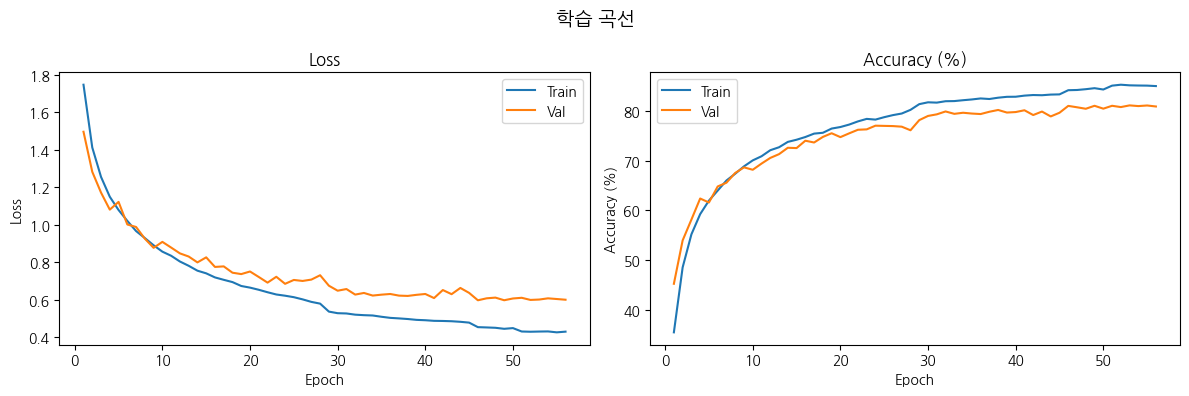

In [19]:
# 실제 학습된 에포크 수 기준으로 x축 생성 (조기 종료 시 NUM_EPOCHS보다 작을 수 있음)
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("학습 곡선", fontsize=14, fontweight="bold")

# 손실 곡선
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# 정확도 곡선
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


##### 테스트 평가

In [20]:
test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.5930  |  Test Accuracy: 80.36%


##### 모델 저장

In [21]:
# 모델을 작업 폴더(Google Drive)에 저장
SAVE_DIR = os.path.join(WORK_DIR, "saved_models_data_augmentation")
os.makedirs(SAVE_DIR, exist_ok=True)

# 모델 구조와 파라미터를 함께 저장
full_path = os.path.join(SAVE_DIR, 'cifar10_classifier_full.pt')
torch.save(model, full_path)
print(f"✓ 전체 모델 저장 완료: {full_path}")

✓ 전체 모델 저장 완료: /google_drive/Othercomputers/내 Mac/sec07/saved_models_data_augmentation/cifar10_classifier_full.pt


##### 저장된 모델로 예측

In [31]:
# full.pt 파일을 이용
pt_path = os.path.join(SAVE_DIR, 'cifar10_classifier_full.pt')
loaded_model = torch.load(pt_path, map_location=device, weights_only=False)

# 모델을 평가 모드로 전환 (Dropout 비활성화)
loaded_model.eval()

# 테스트셋 첫 번째 샘플 얻기
image, label = test_dataset[0]

# 모델 입력 형태로 변환 (배치 차원 추가) 후 디바이스로 이동
input_tensor = image.unsqueeze(0).to(device)  # (1, C, H, W)

# 예측 수행 (gradient 계산 비활성화)
with torch.inference_mode():
    output   = loaded_model(input_tensor)
    pred_idx = output.argmax(dim=1).item()

# 클래스 이름 목록 (예측 결과 해석용)
CLASS_NAMES = test_dataset.classes
print(f"예측 클래스: {CLASS_NAMES[pred_idx]}")
print(f"실제 클래스: {CLASS_NAMES[label]}")

예측 클래스: ship
실제 클래스: airplane
